In [1]:
import albumentations as A
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from auxiliary.model_utils import *
from auxiliary.cnn_class import CNN
from auxiliary.pokemon_dataset import PokemonDataset
from auxiliary.numpy_dataset import NumpyDataset

(null): No such file or directory


In [2]:
DATA_DIR    = "Pokemon"
IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-3
N_FOLDS     = 5
RANDOM_SEED = 42
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
 
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")


Using device: cuda


In [3]:
train_transform = A.Compose([
    A.Resize(64, 64),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(64, 64),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

In [4]:
# 1. Load the .npy files
x_train = np.load('./Pokemon/X_train.npy')
y_train = np.load('./Pokemon/y_train.npy')

x_val = np.load('./Pokemon/X_val.npy')
y_val = np.load('./Pokemon/y_val.npy')

x_test = np.load('./Pokemon/X_test.npy')
y_test = np.load('./Pokemon/y_test.npy')

le = LabelEncoder()
y_train_idx = le.fit_transform(y_train)  
y_val_idx   = le.transform(y_val)        
y_test_idx  = le.transform(y_test)

# Save the class names for later plotting
class_names = le.classes_
print(f"Detected {len(class_names)} classes: {class_names}")

Detected 47 classes: ['arbok' 'beedrill' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'ekans'
 'fearow' 'gloom' 'golbat' 'ivysaur' 'jigglypuff' 'kakuna' 'metapod'
 'nidoking' 'nidoqueen' 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino'
 'ninetales' 'oddish' 'paras' 'parasect' 'pidgeot' 'pidgeotto' 'pidgey'
 'pikachu' 'raichu' 'raticate' 'rattata' 'sandshrew' 'sandslash' 'spearow'
 'squirtle' 'venusaur' 'vileplume' 'vulpix' 'wartortle' 'weedle'
 'wigglytuff' 'zubat']


In [5]:
train_loader = DataLoader(NumpyDataset(x_train, y_train_idx, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NumpyDataset(x_val, y_val_idx, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NumpyDataset(x_test, y_test_idx, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)

In [6]:
# Initialize Model
model = CNN(num_classes=len(le.classes_)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Dictionary to store history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    # Calculate averages
    metrics = {
        "train_loss": train_loss / len(x_train),
        "train_acc":  train_correct / len(x_train),
        "val_loss":   val_loss / len(x_val),
        "val_acc":    val_correct / len(x_val)
    }
    
    for key in history: history[key].append(metrics[key])
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Val Loss: {metrics['val_loss']:.4f} Acc: {metrics['val_acc']:.4f}")

Detected flattened size: 8192
Epoch 01/50 | Train Loss: 3.5292 Acc: 0.0836 | Val Loss: 2.8564 Acc: 0.2596
Epoch 02/50 | Train Loss: 2.7597 Acc: 0.2424 | Val Loss: 2.2565 Acc: 0.3596
Epoch 03/50 | Train Loss: 2.3724 Acc: 0.3311 | Val Loss: 2.0994 Acc: 0.4149
Epoch 04/50 | Train Loss: 2.1174 Acc: 0.3985 | Val Loss: 1.9736 Acc: 0.4404
Epoch 05/50 | Train Loss: 1.9495 Acc: 0.4424 | Val Loss: 1.8683 Acc: 0.4745
Epoch 06/50 | Train Loss: 1.8048 Acc: 0.4844 | Val Loss: 1.8436 Acc: 0.5021
Epoch 07/50 | Train Loss: 1.6862 Acc: 0.5134 | Val Loss: 1.8040 Acc: 0.5170
Epoch 08/50 | Train Loss: 1.5570 Acc: 0.5509 | Val Loss: 1.7809 Acc: 0.5298
Epoch 09/50 | Train Loss: 1.4555 Acc: 0.5821 | Val Loss: 1.7576 Acc: 0.5383
Epoch 10/50 | Train Loss: 1.3593 Acc: 0.6017 | Val Loss: 1.7203 Acc: 0.5468
Epoch 11/50 | Train Loss: 1.2872 Acc: 0.6254 | Val Loss: 1.7178 Acc: 0.5617
Epoch 12/50 | Train Loss: 1.1872 Acc: 0.6480 | Val Loss: 1.7019 Acc: 0.5553
Epoch 13/50 | Train Loss: 1.1118 Acc: 0.6753 | Val Loss: 1

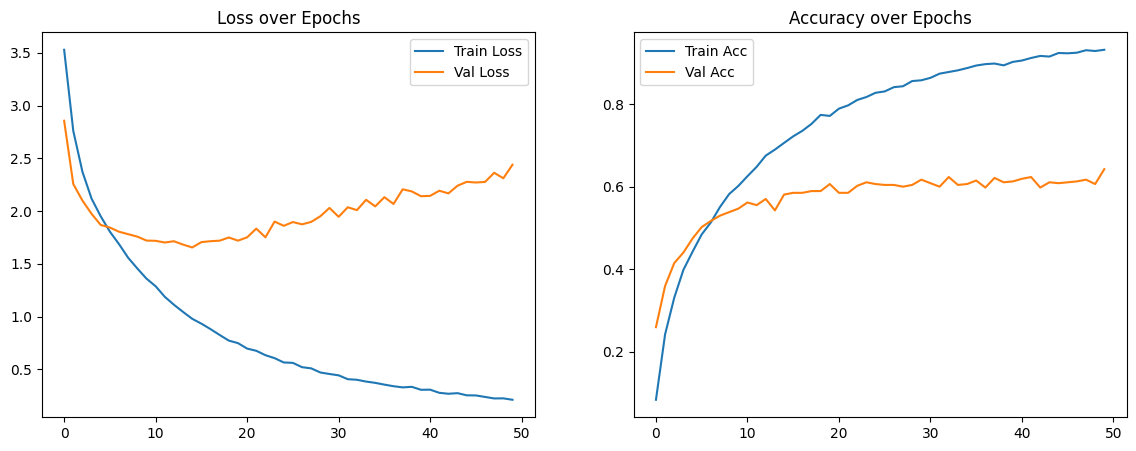


--- Final Test Set Report ---
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.60      0.60      0.60        10
           2       0.75      0.60      0.67        10
           3       0.67      0.80      0.73        10
           4       0.89      0.80      0.84        10
           5       0.67      0.20      0.31        10
           6       0.75      0.90      0.82        10
           7       0.44      0.40      0.42        10
           8       0.56      0.50      0.53        10
           9       0.78      0.70      0.74        10
          10       0.69      0.90      0.78        10
          11       0.67      0.80      0.73        10
          12       0.42      0.50      0.45        10
          13       0.89      0.80      0.84        10
          14       0.90      0.90      0.90        10
          15       0.89      0.80      0.84        10
          16       0.57      0.80      0.67       

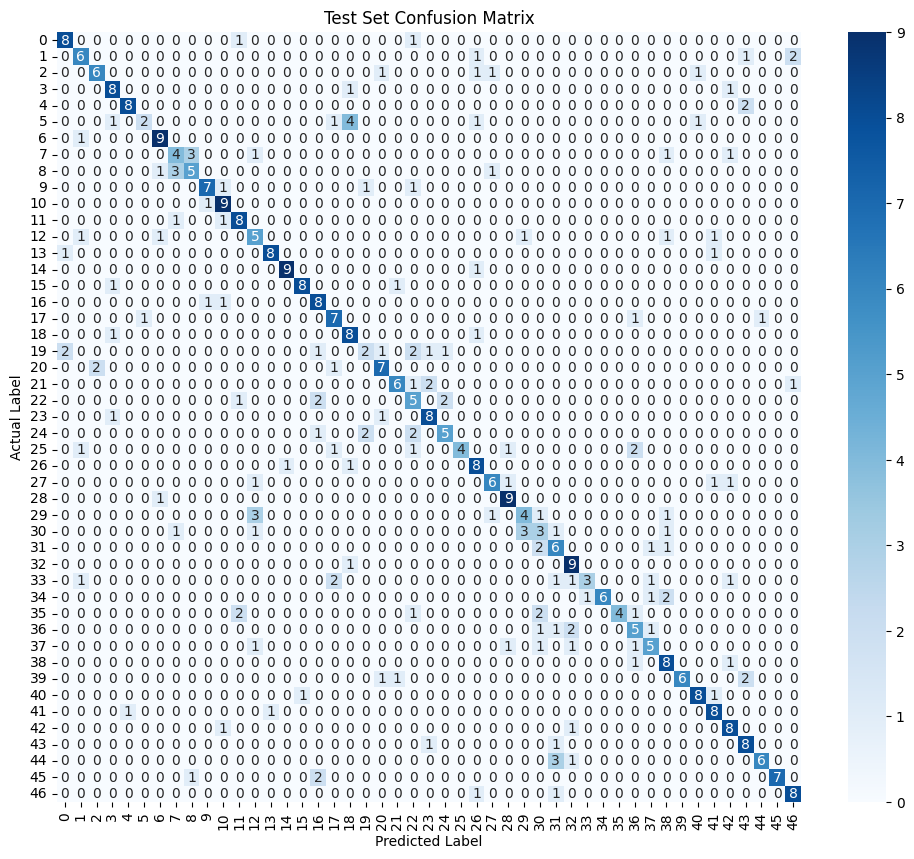

In [7]:
# 1. Plot Training/Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()

ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.set_title("Accuracy over Epochs")
ax2.legend()

plt.show()

# 2. Final Evaluation on Test Set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n--- Final Test Set Report ---")
print(classification_report(all_labels, all_preds))

# 3. Confusion Matrix for Test Set
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()